# Connect to downstream Gene Ontology terms.

This notebook showcases the functionality of Omniflow that connects the existing nodes of a network to a phenotype of interest. 

In [1]:
%%time
from neko.core.network import Network
from neko._visual.visualize_network import NetworkVisualizer
from neko.inputs import Universe
from neko._annotations.gene_ontology import Ontology
import omnipath as op

CPU times: total: 3.64 s
Wall time: 8.18 s


### 1. Build network

Please see the [Network building](https://omniflow-project.readthedocs.io/en/latest/notebooks/network_building.html) tutorial for detailed explanations of each step.

In [2]:
genes = ["SRC", "NOTCH1", "FAK"]

In [3]:
new_net1 = Network(genes, resources = 'omnipath')

In [4]:
%%time
new_net1.connect_nodes(only_signed=True, consensus_only=True)

CPU times: total: 46.9 ms
Wall time: 36.1 ms


### 2. Connect to Gene Ontology (GO) term

The _connect_genes_to_phenotype_ function retrieves genes from the official Gene Ontology API and looks for interactions between those genes and the current network. The GO accession is authoritative, so a phenotype label is not required. The argument _compress_ replaces the connected GO genes with one node carrying the canonical GO term label.

<div class="alert alert-info">

**Note**
    
NeKo uses exact-term annotations by default. Set _include_descendants=True_ when annotations propagated from more specific GO terms should also be included. Broad terms can return many genes, so specific terms are usually easier to interpret.

</div>  

In [ ]:
%%time
new_net1.connect_genes_to_phenotype(id_accession="GO:0001837", only_signed=True, compress=False, maxlen=1, include_descendants=True)

CPU times: total: 641 ms
Wall time: 686 ms


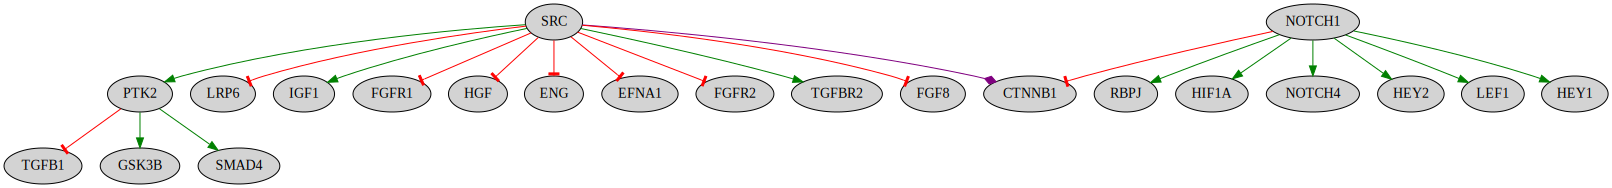

In [41]:
#Visualize network
visualizer1 = NetworkVisualizer(new_net1, color_by='effect')
visualizer1.render()